In [7]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ganes\Downloads\amazon.csv", encoding='latin1')
df.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    6454 non-null   int64  
 1   state   6454 non-null   object 
 2   month   6454 non-null   object 
 3   number  6454 non-null   float64
 4   date    6454 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.2+ KB


year      0
state     0
month     0
number    0
date      0
dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.day
df = df.dropna()

In [10]:
def classify_fire(x):
    if x == 0:
        return 0   
    elif x < 50:
        return 1 
    elif x < 200:
        return 2   
    else:
        return 3 
df['fire_class'] = df['number'].apply(classify_fire)

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['state'] = le.fit_transform(df['state'])
df['month'] = le.fit_transform(df['month'])

In [12]:
X = df[['year', 'state', 'month', 'day']]
y = df['fire_class']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6312935708752905

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.51      0.56       134
           1       0.70      0.77      0.73       695
           2       0.49      0.46      0.47       265
           3       0.53      0.47      0.50       197

    accuracy                           0.63      1291
   macro avg       0.59      0.55      0.57      1291
weighted avg       0.62      0.63      0.63      1291


Confusion Matrix:
 [[ 69  61   2   2]
 [ 38 532  82  43]
 [  3 103 122  37]
 [  1  60  44  92]]


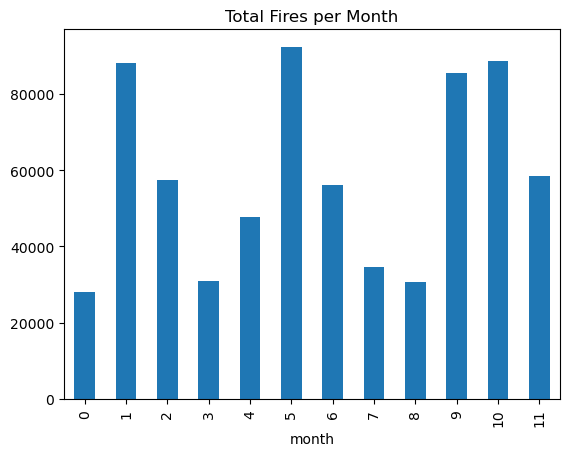

In [16]:
import matplotlib.pyplot as plt
df.groupby('month')['number'].sum().plot(kind='bar')
plt.title("Total Fires per Month")
plt.show()

In [17]:
import joblib
joblib.dump(model, "forest_fire_model.pkl")

['forest_fire_model.pkl']